# 05 — Results: collation across all schemes — CIC-IDS-2017 — Mutual Information study

Reads every `runs/<scheme>/<model>/metrics.json` plus the CV tables and produces the
comparison tables and plots. **Every number here comes from a saved artifact file.**
The final section also compares this study's selected features against the base
(RF-importance) study's top 40, when that study's artifacts are present.

In [1]:
DATASET = "cic2017"
FT_ROOT = "ft40_mi"

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids import config
from ids.evaluation.cross_val import METRIC_NAMES

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "05_results.log", "nb05")

rows = []
for mp in sorted(P.runs.glob("*/*/metrics.json")):
    d = nbc.load_json(mp)
    for split in ("test", "validation"):
        if split in d:
            m = {k: v for k, v in d[split].items() if k != "name"}
            rows.append({"scheme": d["scheme"], "model": d["model"], "split": split,
                         "n_train": d["n_train"], "fit_seconds": d["fit_seconds"], **m})
summary = pd.DataFrame(rows)
summary.to_csv(P.results / "summary_all_schemes.csv", index=False)
log.info("collected %d (scheme, model, split) results", len(summary))
summary.head(10)

2026-07-06 13:07:40,277 INFO nb05: collected 25 (scheme, model, split) results


,scheme,model,split,n_train,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,detection_time_ms,n_test
0,70_20_10,decision_tree,test,1764558,16.582,0.995359,0.747986,0.917499,0.802502,0.997796,0.000382,252080
1,70_20_10,decision_tree,validation,1764558,16.582,0.995077,0.713533,0.905301,0.775473,0.997718,0.000226,504160
2,70_20_10,knn,test,1764558,2.659,0.966388,0.585596,0.915865,0.655540,0.991701,0.446473,252080
3,70_20_10,knn,validation,1764558,2.659,0.965924,0.609159,0.897650,0.666234,0.991650,0.446183,504160
4,70_20_10,naive_bayes,test,1764558,3.202,0.351047,0.282052,0.641351,0.270887,0.942679,0.001173,252080
5,70_20_10,naive_bayes,validation,1764558,3.202,0.351730,0.348487,0.641028,0.336497,0.942265,0.000703,504160
6,70_20_10,random_forest,test,1764558,39.466,0.995866,0.753482,0.848980,0.778838,0.999907,0.002871,252080
7,70_20_10,random_forest,validation,1764558,39.466,0.995497,0.815077,0.893508,0.828191,0.999905,0.002850,504160
8,70_20_10,svm,test,1764558,10.122,0.690198,0.290489,0.770084,0.321225,0.949537,0.001035,252080
9,70_20_10,svm,validation,1764558,10.122,0.689688,0.289659,0.805243,0.321045,0.948520,0.001507,504160


## 1. Test-set comparison: model × scheme, one table per metric

In [3]:
test = summary[summary["split"] == "test"]
pivots = {}
for metric in METRIC_NAMES + ["detection_time_ms", "fit_seconds"]:
    pv = test.pivot_table(index="model", columns="scheme", values=metric).round(4)
    pv.to_csv(P.results / f"pivot_{metric}.csv")
    pivots[metric] = pv
log.info("saved %d pivot tables to %s", len(pivots), P.results)
pivots["f1_macro"]

2026-07-06 13:07:40,309 INFO nb05: saved 7 pivot tables to /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2017/results


scheme,70_20_10,70_30,80_20,90_10
model,,,,
decision_tree,0.8025,0.7695,0.7757,0.8105
knn,0.6555,0.6536,0.6402,0.6335
naive_bayes,0.2709,0.3185,0.3064,0.2629
random_forest,0.7788,0.7922,0.8225,0.7785
svm,0.3212,0.3291,0.3355,0.3286


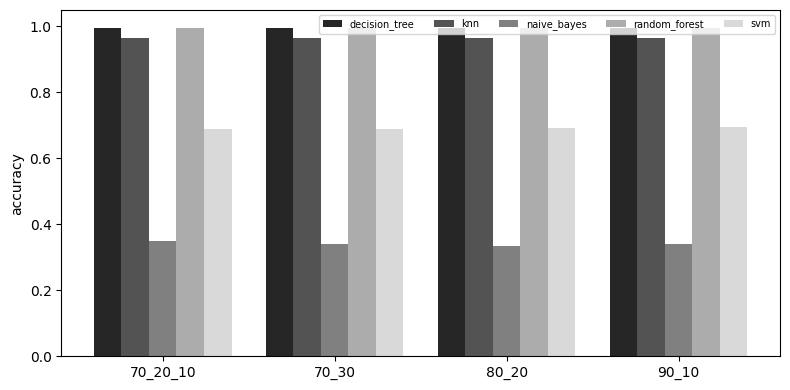

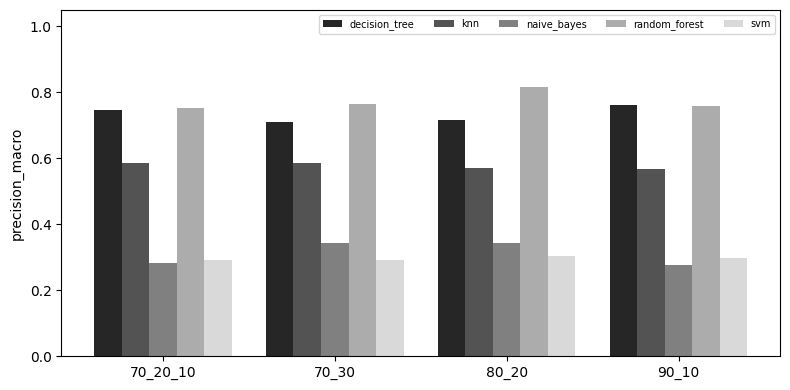

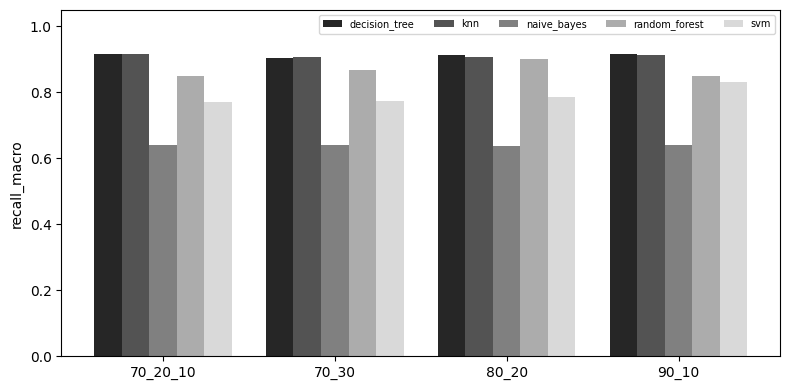

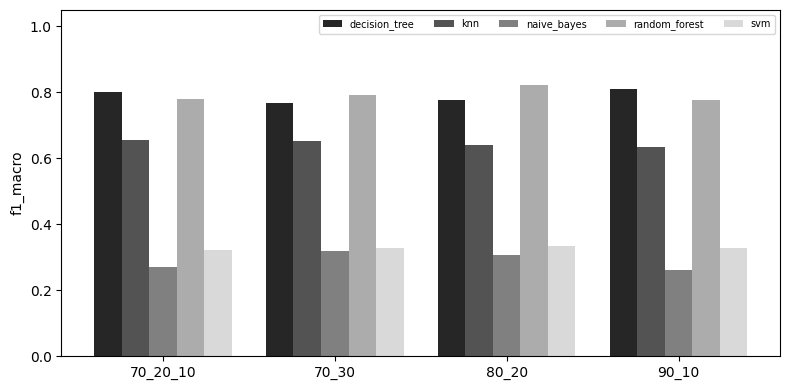

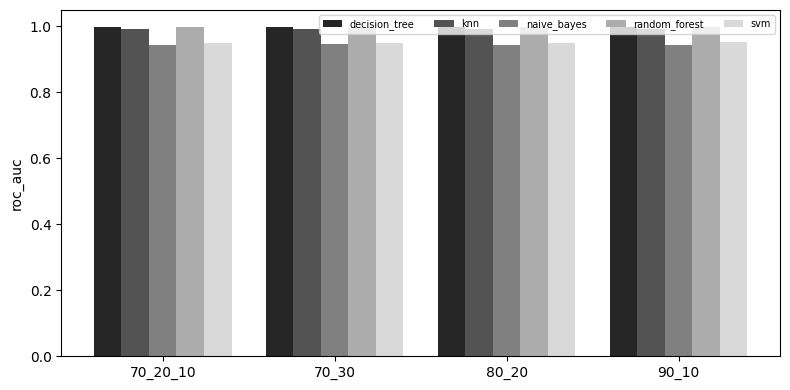

In [4]:
for metric in METRIC_NAMES:
    pv = pivots[metric]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pv.columns))
    width = 0.8 / len(pv.index)
    for i, model in enumerate(pv.index):
        ax.bar(x + i * width, pv.loc[model], width,
               label=model, color=str(0.15 + 0.7 * i / max(1, len(pv.index) - 1)))
    ax.set_xticks(x + 0.4 - width / 2)
    ax.set_xticklabels(pv.columns)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, ncol=len(pv.index))
    fig.tight_layout()
    fig.savefig(P.results / "plots" / f"{metric}_by_scheme.png", dpi=150)
    plt.show()

## 2. Cross-validation (cv5): mean ± std per model

In [5]:
cv_summary_path = P.runs / "cv5" / "cv_summary.csv"
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    cv_summary.to_csv(P.results / "cv5_summary.csv", index=False)
    display(cv_summary.round(4))
else:
    log.warning("no cv5 results found at %s", cv_summary_path)

,model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,decision_tree,0.9945,0.0002,0.7203,0.0134,0.9157,0.0224,0.7753,0.0108,0.9978,0.0002
1,knn,0.9649,0.0007,0.5772,0.0198,0.8966,0.0071,0.6431,0.0180,0.9914,0.0002
2,naive_bayes,0.3487,0.0082,0.3149,0.0311,0.6499,0.0258,0.2985,0.0257,0.9444,0.0020
3,random_forest,0.9947,0.0004,0.7941,0.0272,0.8956,0.0146,0.8102,0.0112,0.9999,0.0000
4,svm,0.6797,0.0046,0.2966,0.0039,0.7840,0.0327,0.3274,0.0039,0.9488,0.0012


## 3. Validation vs test on the 70/20/10 scheme

In [6]:
vt = summary[summary["scheme"] == "70_20_10"].pivot_table(
    index="model", columns="split",
    values=[m for m in METRIC_NAMES if m in summary.columns]).round(4)
vt.to_csv(P.results / "val_vs_test_70_20_10.csv")
vt

accuracy            f1_macro            precision_macro  \
split             test validation     test validation            test   
model                                                                   
decision_tree   0.9954     0.9951   0.8025     0.7755          0.7480   
knn             0.9664     0.9659   0.6555     0.6662          0.5856   
naive_bayes     0.3510     0.3517   0.2709     0.3365          0.2821   
random_forest   0.9959     0.9955   0.7788     0.8282          0.7535   
svm             0.6902     0.6897   0.3212     0.3210          0.2905   

                         recall_macro            roc_auc             
split         validation         test validation    test validation  
model                                                                
decision_tree     0.7135       0.9175     0.9053  0.9978     0.9977  
knn               0.6092       0.9159     0.8976  0.9917     0.9916  
naive_bayes       0.3485       0.6414     0.6410  0.9427     0.9423  
random_forest     0.8151       0.8490     0.8935  0.9999     0.9999  
svm               0.2897       0.7701     0.8052  0.9495     0.9485

## 4. Feature-set overlap with the base (RF-importance) study

In [7]:
mine = nbc.load_json(P.features / "top40.json")
base_path = config.ARTIFACTS_DIR / "ft40" / DATASET / "features" / "top40.json"
if base_path.exists():
    base = nbc.load_json(base_path)
    shared = sorted(set(mine["selected"]) & set(base["selected"]))
    only_mine = sorted(set(mine["selected"]) - set(base["selected"]))
    only_base = sorted(set(base["selected"]) - set(mine["selected"]))
    overlap = {"method": mine.get("method"), "n_shared_with_rf_importance": len(shared),
               "shared": shared, "only_this_method": only_mine, "only_rf_importance": only_base}
    nbc.save_json(overlap, P.results / "feature_overlap_vs_base.json")
    log.info("%d/40 features shared with the RF-importance study", len(shared))
    print(f"shared with base study: {len(shared)}/40")
else:
    log.warning("base study top40 not found at %s — overlap skipped", base_path)

2026-07-06 13:07:40,778 INFO nb05: 33/40 features shared with the RF-importance study
shared with base study: 33/40


## 5. Artifact inventory (what backs every number above)

In [8]:
inventory = sorted(str(p.relative_to(P.root)) for p in P.root.rglob("*") if p.is_file())
nbc.save_json(inventory, P.results / "artifact_inventory.json")
log.info("study produced %d artifact files under %s", len(inventory), P.root)
print(f"{len(inventory)} files; key results:")
for f in inventory:
    if f.startswith("results/") and f.endswith(".csv"):
        print(" ", f)

2026-07-06 13:07:40,791 INFO nb05: study produced 183 artifact files under /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2017
183 files; key results:
  results/cv5_summary.csv
  results/pivot_accuracy.csv
  results/pivot_detection_time_ms.csv
  results/pivot_f1_macro.csv
  results/pivot_fit_seconds.csv
  results/pivot_precision_macro.csv
  results/pivot_recall_macro.csv
  results/pivot_roc_auc.csv
  results/summary_all_schemes.csv
  results/val_vs_test_70_20_10.csv
